#Clase 2. Analisis Exploratorio de un dataset

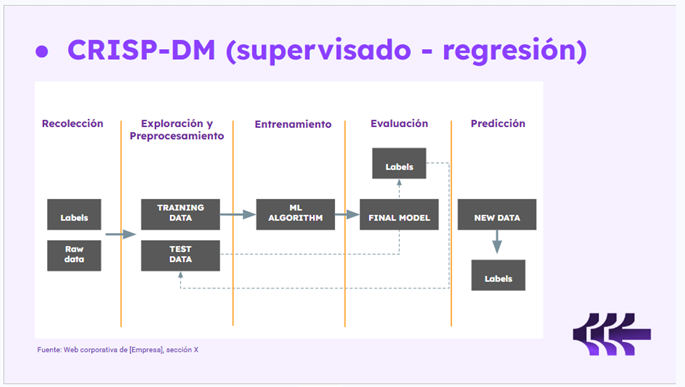

##Carga del fichero desde Kaggle

In [1]:
#configuramos importacion desde kaggle
from google.colab import files
!pip install -q kaggle

In [2]:
#subimos kaggle.json con el cliente
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
#descargamos dataset
!kaggle datasets download -d mirichoi0218/insurance

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
100% 16.0k/16.0k [00:00<00:00, 33.3MB/s]



In [4]:
#descomprimimos el dataset
!unzip insurance.zip

Archive:  insurance.zip
  inflating: insurance.csv           


##Fase Exploración (Analítica)

In [5]:
#Cargar libreria
import pandas as pd

In [6]:
#creamos variable con dataset
data=pd.read_csv("./insurance.csv")

In [7]:
#nombre de las columnas
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [8]:
#consultar el numero de filas y columnas
data.shape

(1338, 7)

In [ ]:
#exploracion del dataset
data

In [9]:
#primeros datos del dataset
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
#datos estadisticos
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [11]:
#tipos de datos de las columnas
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [12]:
#Verificar valores nulos
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


##Fase Exploración (Visual)

In [13]:
#Cargar libreria
import matplotlib.pyplot as plt
import seaborn as sns

**Histogramas**

Los histogramas tienen sentido en variables numéricas continuas o discretas, donde queremos observar la distribución de valores.

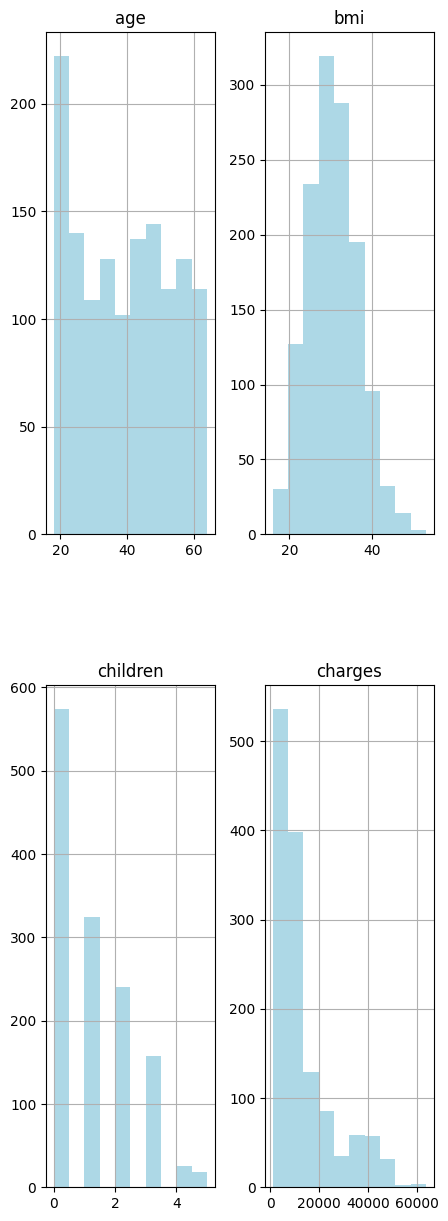

In [14]:
data.hist(figsize=(5,15),  color ='lightblue')
plt.show()

**Diagrama de barras**

Exploramos diagramas de barras para variables categóricas o discretas (variables con un número limitado de valores específicos), ya que los diagramas de barras son útiles para visualizar la frecuencia o la distribución de estas categorías.

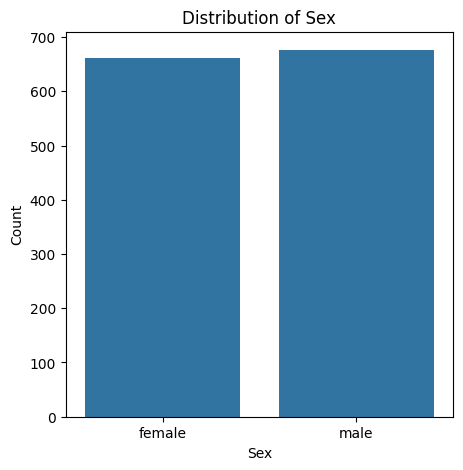

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 5))
sns.countplot(data, x='sex')
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()


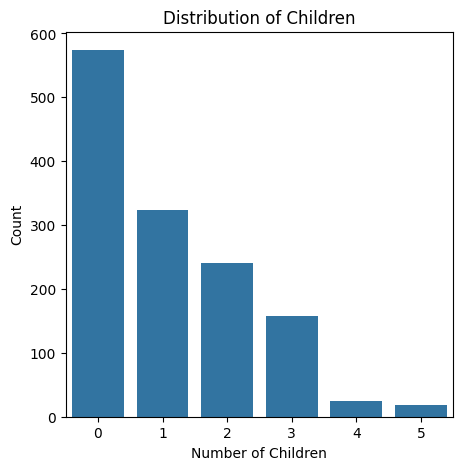

In [16]:
plt.figure(figsize=(5, 5))
sns.countplot(data, x='children')
plt.title('Distribution of Children')
plt.xlabel('Number of Children')
plt.ylabel('Count')
plt.show()


También podemos utilizar los diagramas de barras cuando queremos graficar el promedio o alguna otra medida de una variable numérica agrupada por categorías. Para este dataset, podríamos usar barplot() para ver, por ejemplo, el promedio de charges agrupado por cada categoría en variables como sex, children, smoker y regions, tal y como se muestra a continuación:

<Axes: xlabel='children', ylabel='charges'>

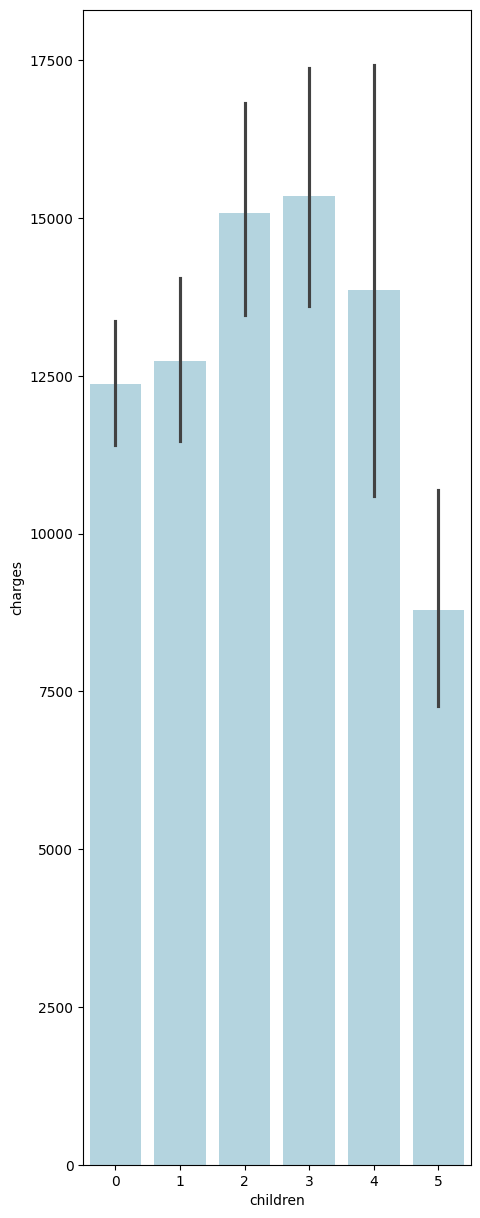

In [18]:
plt.figure(figsize=(5,15))
sns.barplot(x=data["children"],y=data["charges"],color = "lightblue")

**Scatter**

Un gráfico de dispersión, o scatter plot, es ideal para analizar la relación entre dos variables numéricas. Cada punto en un scatter representa un par de valores, permitiendo observar patrones, correlaciones o tendencias entre las variables.

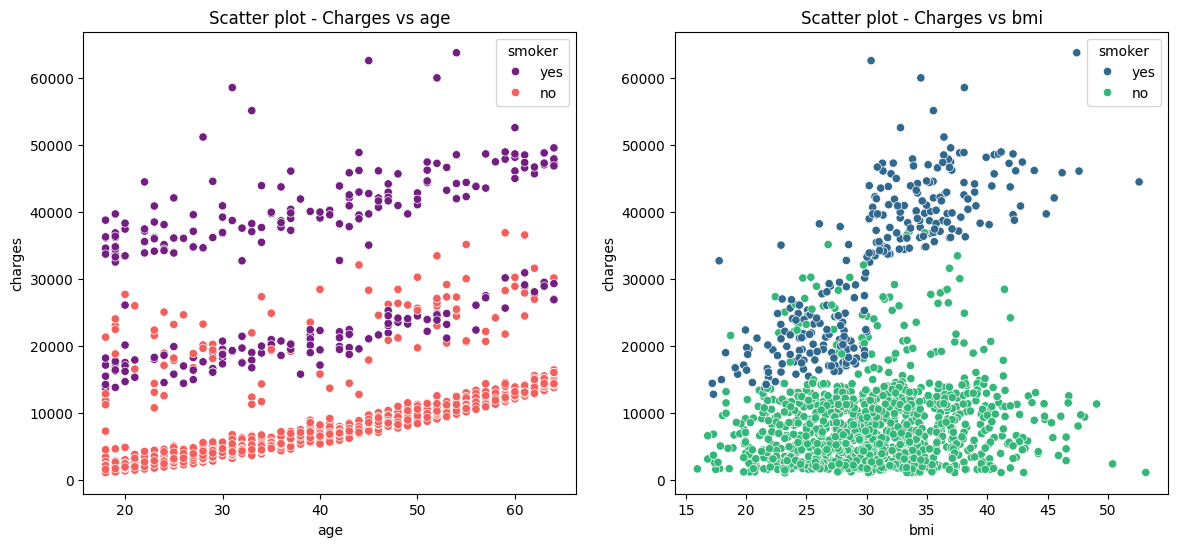

In [19]:
f = plt.figure(figsize=(14,6))
ax = f.add_subplot(121)
sns.scatterplot(x='age',y='charges',data=data,palette='magma',hue='smoker',ax=ax)
ax.set_title('Scatter plot - Charges vs age')

ax = f.add_subplot(122)
sns.scatterplot(x='bmi',y='charges',data=data,palette='viridis',hue='smoker')
ax.set_title('Scatter plot - Charges vs bmi')
plt.savefig('sc.png');

**Mapa de correlación**

Un mapa de correlación, o heatmap, es una excelente herramienta para visualizar la relación entre variables numéricas en un dataset. Muestra una matriz de correlación donde cada celda representa el grado de correlación (medido de -1 a 1) entre dos variables, lo cual es útil para identificar relaciones lineales.

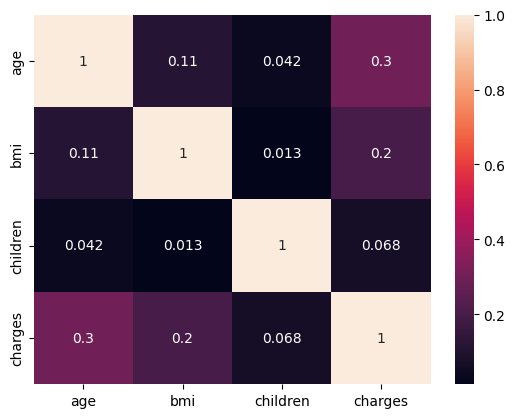

In [20]:
corr = data.corr(numeric_only = True)
sns.heatmap(corr, annot= True);

##Conclusiones


El dataset de seguros, contiene 1338 registros con 7 columnas (4 variables numericas: age, bmi, children,charges; 3 variables categoricas: smoker, region, y sex). Noy hay valores nulos.

**Algunas de las principales conclusiones del análisis exploratorio son:**

*  La media de edad es de 39.21 años, con un rango de 18 a 64 años. Un 25% de los individuos tiene entre 18 y 27 años. La edad tiene una correlación moderada con los cargos médicos, indicando que los costos tienden a aumentar con la edad.

*  El BMI promedio es 30.66, indicando que la mayoría de los individuos están en el rango de sobrepeso. El BMI tiene una correlación débil con los cargos.

*  La mayoría de los individuos tiene pocos hijos, con una media de aproximadamente 1 hijo. La cantidad de hijos tiene una correlación muy débil con los cargos médicos y otras variables

*  Hay una distribución equilibrada entre las diferentes regiones, con un pequeño aumento en el sureste del país. Las diferentes regiones no parecen tener una influencia significativa en los cargos médicos.

*  La distribución es equilibrada entre hombres y mujeres. La mayoría de hombres y mujeres no son fumadores.

*  Los fumadores tienden a tener cargos médicos significativamente más altos que los no fumadores.



**Conclusiones del análisis de correlación:**

El análisis de la matriz de correlación permite identificar la relación lineal entre las variables numéricas del dataset.

*  En primer lugar, la variable **charges** (costes médicos) muestra una correlación positiva moderada con la **edad (age)**, en torno a 0.30. Esto sugiere que, a medida que aumenta la edad, los costes tienden a incrementarse, aunque la relación no es especialmente fuerte.

*  Por otro lado, la relación entre **bmi** (índice de masa corporal) y **charges** es positiva pero más débil (aproximadamente 0.20), lo que indica que el IMC puede influir en los costes, pero no es un factor determinante por sí solo.

*  La variable **children** presenta una correlación muy baja con **charges** (alrededor de 0.07), lo que sugiere que el número de hijos no tiene un impacto significativo en los costes médicos dentro de este dataset.

*  Asimismo, se observa que las correlaciones entre las variables explicativas (age, bmi y children) son muy bajas, lo que indica que no existe multicolinealidad relevante entre ellas. Esto es positivo desde el punto de vista del modelado, ya que las variables aportan información relativamente independiente.

